In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data[:,2:]
y = iris.target

print(X.shape)
print(y.shape)

(150, 2)
(150,)


In [16]:
#creating the viting calssifier

from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
log_clf = LogisticRegression()
rnd_clf = RandomForestClassifier()
svm_clf = SVC()


voting_clf = VotingClassifier(
    estimators = [
        ('lr', log_clf),
        ('rf', rnd_clf),
        ('svc', svm_clf)
    ],
    voting = "hard"
)
voting_clf.fit(X, y)

VotingClassifier(estimators=[('lr', LogisticRegression()),
                             ('rf', RandomForestClassifier()), ('svc', SVC())])

In [17]:
from sklearn.metrics import accuracy_score
for c in (log_clf, rnd_clf, svm_clf, voting_clf):
    c.fit(X,y)
    y_pred = c.predict(X)
    print(c.__class__.__name__, accuracy_score(y, y_pred))

LogisticRegression 0.9666666666666667
RandomForestClassifier 0.9933333333333333
SVC 0.9533333333333334
VotingClassifier 0.9666666666666667


In [18]:
import matplotlib.pyplot as plt
from sklearn.inspection import DecisionBoundaryDisplay

def plot_ensemble_boundaries(models, names, x, y):
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    for ax, model, name in zip(axes.ravel(), models, names):
        DecisionBoundaryDisplay.from_estimator(
            model,
            x,
            response_method="predict",
            cmap=plt.cm.coolwarm,
            alpha=0.6,
            ax=ax
        )

        ax.scatter(
            x[:, 0], x[:, 1],
            c=y,
            cmap=plt.cm.coolwarm,
            edgecolor="black",
            s=30
        )

        ax.set_title(name)

    plt.tight_layout()
    plt.show()

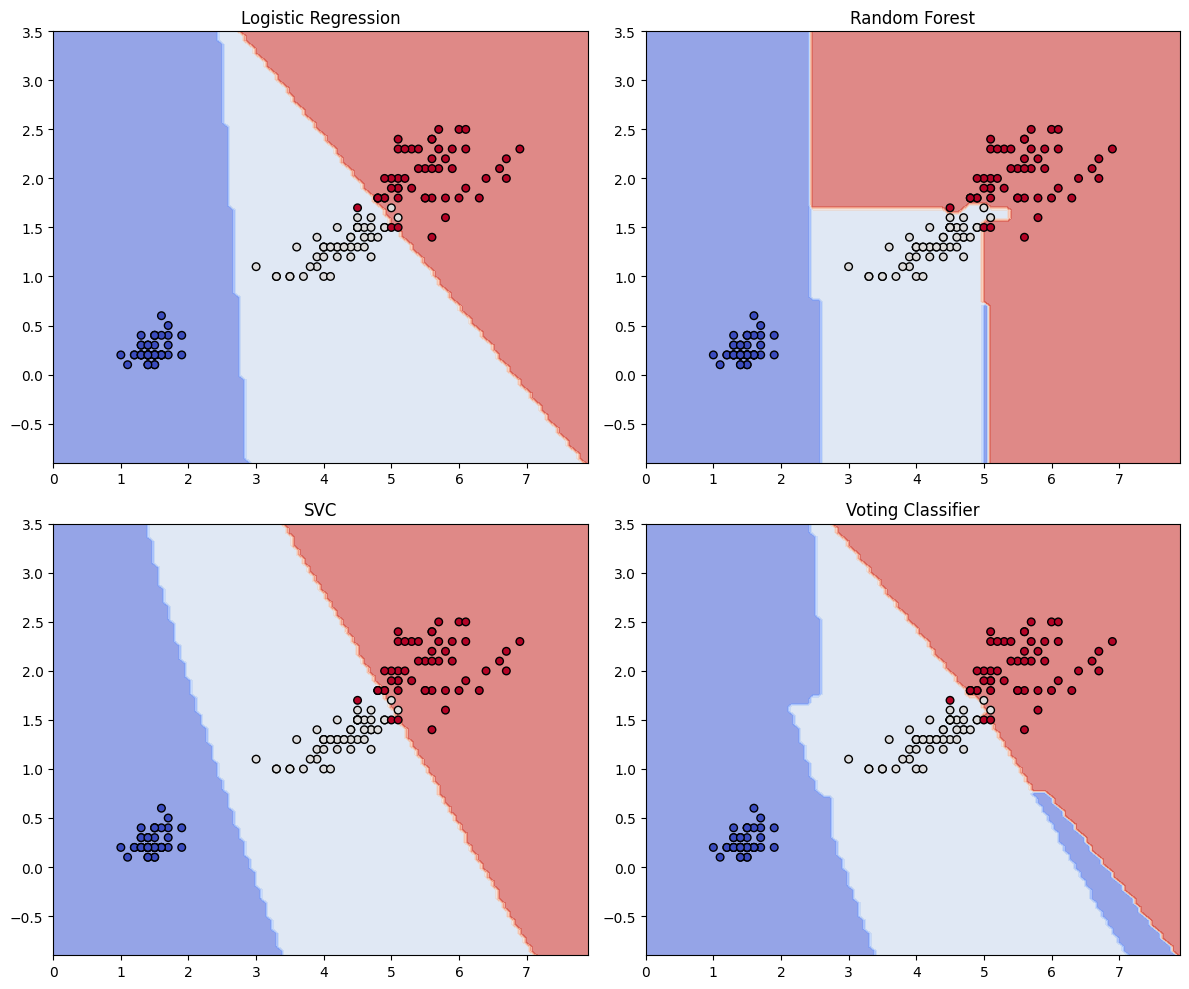

In [19]:
models_list = [log_clf, rnd_clf, svm_clf, voting_clf]
model_names = ["Logistic Regression", "Random Forest", "SVC", "Voting Classifier"]

plot_ensemble_boundaries(models_list, model_names, X, y)